<a href="https://colab.research.google.com/github/c0b23144/oxford_pet_diffusion_generate/blob/main/oxford_pet_generate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install -q torch torchvision

In [1]:
# モデル保存
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode

transform = transforms.Compose([
    transforms.Resize(
        (128, 128),
        interpolation=InterpolationMode.BICUBIC
        ),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=transform,
    download=True
)

print("画像枚数:", len(dataset))

100%|██████████| 792M/792M [00:31<00:00, 25.3MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.6MB/s]


画像枚数: 3680


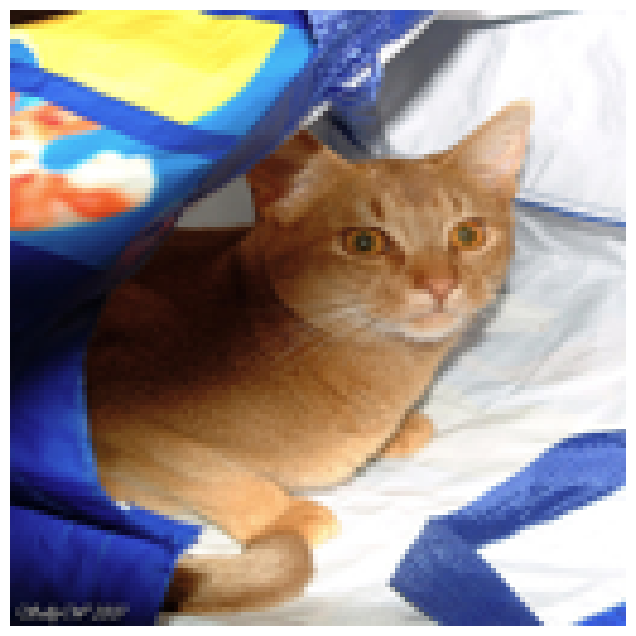

ラベル: 0


In [3]:
import matplotlib.pyplot as plt

image, label = dataset[0]

# -1～1 ⇒ 0～1に戻す
image = image * 0.5 + 0.5

plt.figure(figsize=(8, 8))
plt.imshow(image.permute(1, 2, 0))
plt.axis("off")
plt.show()

print("ラベル:", label)

In [4]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

# diffusionのステップ数
T = 1000

# ノイズの強さ
beta = torch.linspace(
    0.0001,
    0.02,
    T,
    device=device
)

alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def add_noise(x, t):
    # ランダムなノイズ
    noise = torch.randn_like(x)

    # その時点での画像の残り具合
    a = alpha_bar[t]
    a = a.view(-1, 1, 1, 1)

    # 画像にノイズを加える
    noisy_image = (
        torch.sqrt(a) * x
        + torch.sqrt(1 - a) * noise
    )

    return noisy_image, noise


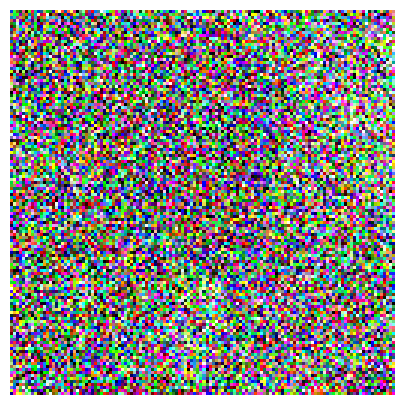

In [5]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

images, labels = next(iter(loader))
images = images.to(device)

# 500段階目までノイズを加える
# 16枚全部を「500段階目」のノイズ状態にする
# 16枚はbatch_size

t = torch.full(
    (images.shape[0],),
    500,
    device = device,
    dtype=torch.long
)

noisy_images, noise = add_noise(images, t)

# 表示
image = noisy_images[0]
image = image * 0.5 + 0.5
image = image.clamp(0, 1)

plt.figure(figsize=(5, 5))
plt.imshow(image.permute(1, 2, 0).cpu())
plt.axis("off")
plt.show()

In [7]:
import math
import torch.nn as nn

# 時間tをベクトルに変換
class TimeEmbedding(nn.Module):

    def __init__(self, dim):
        super().__init__()

        self.dim = dim

        # sin/cosで作った時間情報をさらに2層のMLPで変換
        self.mlp = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.SiLU(),
            nn.Linear(dim * 4, dim * 4)
        )

    def forward(self, t):
        half = self.dim // 2
        emb = math.log(10000) / (half - 1)

        emb = torch.exp(
            torch.arange(
                half,
                device=t.device
            ) * -emb
        )

        # 64個のsin + 64個のcos = dim(128)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat(
            (emb.sin(), emb.cos()),
            dim=1
        )

        # 時間情報をさらに変換
        emb = self.mlp(emb)

        return emb

# 畳み込みブロック
class Block(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim, dropout=0.1):
        super().__init__()

        # Normalization
        if in_channels % 8 == 0:
            self.norm1 = nn.GroupNorm(8, in_channels)
        else:
            self.norm1 = nn.GroupNorm(1, in_channels)

        self.norm2 = nn.GroupNorm(
            8,
            out_channels
        )

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            padding=1
        )

        self.time = nn.Linear(
            time_dim,
            out_channels
        )

        # Dropout
        self.dropout = nn.Dropout(dropout)

        # 活性化関数
        self.act = nn.SiLU()

        # 入力と出力のチャネル数が違う場合に変換
        if in_channels != out_channels:
            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else:
            self.skip = nn.Identity()

    def forward(self, x, t):
        # 元の入力を保存
        residual = self.skip(x)

        x = self.norm1(x)
        x = self.act(x)
        x = self.conv1(x)

        # 時間情報を画像に追加
        time = self.time(t)
        time = time[:, :, None, None]

        x = x + time

        x = self.norm2(x)
        x = self.act(x)
        # Dropout
        x = self.dropout(x)
        x = self.conv2(x)

        # 元の入力を足す
        x = x + residual

        return x

# multi-head-attention add
class MultiHeadAttention(nn.Module):
    def __init__(self, channels, num_heads=4):
        super().__init__()

        assert channels % num_heads == 0

        self.channels = channels
        self.num_heads = num_heads
        self.head_dim = channels // num_heads

        self.qkv = nn.Conv2d(
            channels,
            channels * 3,
            kernel_size = 1
        )

        # Attention後の変換
        self.out = nn.Conv2d(
            channels,
            channels,
            kernel_size=1
        )

        self.norm = nn.GroupNorm(
            8,
            channels
        )

    def forward(self, x):
        residual = x

        # Normalization
        x = self.norm(x)

        B, C, H, W = x.shape

        # Q,K,Vを作る
        qkv = self.qkv(x)

        q, k, v = torch.chunk(
            qkv,
            3,
            dim=1
        )

        # Multi-Head用に形を変える
        q = q.view(
            B,
            self.num_heads,
            self.head_dim,
            H * W
        )

        k = k.view(
            B,
            self.num_heads,
            self.head_dim,
            H * W
        )

        v = v.view(
            B,
            self.num_heads,
            self.head_dim,
            H * W
        )

        # Q,K,Vを
        # [B, heads, tokens, head_dim]にする
        q = q.transpose(2, 3)
        k = k.transpose(2, 3)
        v = v.transpose(2, 3)

        # Attention
        attention = torch.matmul(
            q,
            k.transpose(-2, -1)
        )
        attention = attention / math.sqrt(
            self.head_dim
        )
        attention = torch.softmax(
            attention,
            dim=-1
        )

        # Attention × V
        x = torch.matmul(
            attention,
            v
        )

        # 元の形に戻す
        x = x.transpose(2, 3)

        x = x.contiguous().view(
            B,
            C,
            H,
            W
        )

        # 出力変換
        x = self.out(x)

        # Residual
        x = x + residual

        return x

# diffusion用 Unet
class UNet(nn.Module):

    def __init__(self):

        super().__init__()

        # Time Embedding

        time_dim = 128

        self.time_embedding = TimeEmbedding(
            time_dim
        )

        # TimeEmbeddingの出力は
        # 128 × 4 = 512
        time_dim_out = time_dim * 4

        # Encoder
        # 128 × 128
        self.down1 = Block(
            3,
            64,
            time_dim_out
        )
        self.down1_2 = Block(
            64,
            64,
            time_dim_out
        )
        # MaxPoolではなくConvでDownsample
        self.downsample1 = nn.Conv2d(
            64,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )
        # 64 × 64
        self.down2 = Block(
            128,
            128,
            time_dim_out
        )
        self.down2_2 = Block(
            128,
            128,
            time_dim_out
        )
        # 64×64 → 32×32
        self.downsample2 = nn.Conv2d(
            128,
            256,
            kernel_size=4,
            stride=2,
            padding=1
        )
        # 32 × 32
        self.down3 = Block(
            256,
            256,
            time_dim_out
        )
        self.down3_2 = Block(
            256,
            256,
            time_dim_out
        )
        # 32×32でAttention
        self.attention32 = MultiHeadAttention(
            256,
            num_heads=8
        )
        # 32×32 → 16×16
        self.downsample3 = nn.Conv2d(
            256,
            256,
            kernel_size=4,
            stride=2,
            padding=1
        )

        # Middle
        # 16 × 16
        self.middle1 = Block(
            256,
            256,
            time_dim_out
        )
        # 16×16 Attention
        self.attention16 = MultiHeadAttention(
            256,
            num_heads=8
        )
        self.middle2 = Block(
            256,
            256,
            time_dim_out
        )

        # Decoder
        # ConvTranspose2dは小さい特徴マップ⇒大きい特徴マップにするために使う
        # 16×16 → 32×32
        self.up3 = nn.ConvTranspose2d(
            256,
            256,
            kernel_size=4,
            stride=2,
            padding=1
        )
        # skip connection
        # 256 + 256 = 512
        self.up_block3 = Block(
            512,
            256,
            time_dim_out
        )
        self.up_block3_2 = Block(
            256,
            256,
            time_dim_out
        )
        # 32×32 Attention
        self.up_attention32 = MultiHeadAttention(
            256,
            num_heads=8
        )
        # 32×32 → 64×64
        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=4,
            stride=2,
            padding=1
        )
        # skip
        # 128 + 128 = 256
        self.up_block2 = Block(
            256,
            128,
            time_dim_out
        )
        self.up_block2_2 = Block(
            128,
            128,
            time_dim_out
        )
        # 64×64 → 128×128
        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=4,
            stride=2,
            padding=1
        )
        # skip
        # 64 + 64 = 128
        self.up_block1 = Block(
            128,
            64,
            time_dim_out
        )
        self.up_block1_2 = Block(
            64,
            64,
            time_dim_out
        )

        # Output
        self.out = nn.Conv2d(
            64,
            3,
            kernel_size=1
        )


    def forward(self, x, t):
        # Time Embedding
        t = self.time_embedding(t)

        # Encoder
        # 128×128
        x1 = self.down1(
            x,
            t
        )
        x1 = self.down1_2(
            x1,
            t
        )
        # 128 → 64
        x = self.downsample1(x1)
        # 64×64
        x2 = self.down2(
            x,
            t
        )
        x2 = self.down2_2(
            x2,
            t
        )
         # 64 → 32
        x = self.downsample2(x2)
        # 32×32
        x3 = self.down3(
            x,
            t
        )
        x3 = self.down3_2(
            x3,
            t
        )
        # Attention
        x3 = self.attention32(x3)
        # 32 → 16
        x = self.downsample3(x3)

        # Middle
        x = self.middle1(
            x,
            t
        )
        # Attention
        x = self.attention16(x)

        x = self.middle2(
            x,
            t
        )

        # Decoder
        # 16 → 32
        x = self.up3(x)
        # Skip Connection
        x = torch.cat(
            [x, x3],
            dim=1
        )
        x = self.up_block3(
            x,
            t
        )
        x = self.up_block3_2(
            x,
            t
        )
        # Attention
        x = self.up_attention32(x)
        # 32 → 64
        x = self.up2(x)
        # Skip Connection
        x = torch.cat(
            [x, x2],
            dim=1
        )
        x = self.up_block2(
            x,
            t
        )
        x = self.up_block2_2(
            x,
            t
        )
        # 64 → 128
        x = self.up1(x)

        # Skip Connection
        x = torch.cat(
            [x, x1],
            dim=1
        )
        x = self.up_block1(
            x,
            t
        )
        x = self.up_block1_2(
            x,
            t
        )

        # Output
        x = self.out(x)

        return x

model = UNet().to(device)

print("U-Netを作りました")
print(
    "パラメータ数:",
    sum(p.numel() for p in model.parameters())
)

U-Netを作りました
パラメータ数: 15189641


In [8]:
# 学習する前にちゃんとデータを通せるか
# 画像を1バッチ取得
images, labels = next(iter(loader))

# GPUへ
images = images.to(device)

# ランダムなtを作る
t = torch.randint(
    0,
    T,
    (images.shape[0],),
    device=device
)

# ノイズを作る
noise = torch.randn_like(images)

# tに応じてノイズを加える
a = alpha_bar[t]
a = a.view(-1, 1, 1, 1)

noisy_images = (
    torch.sqrt(a) * images
    + torch.sqrt(1 - a) * noise
)

# U-Netに入力
predicted_noise = model(
    noisy_images,
    t
)

print("入力画像:", noisy_images.shape)
print("本物のノイズ:", noise.shape)
print("予測ノイズ:", predicted_noise.shape)

入力画像: torch.Size([16, 3, 128, 128])
本物のノイズ: torch.Size([16, 3, 128, 128])
予測ノイズ: torch.Size([16, 3, 128, 128])


In [9]:
# Lossの計算
import torch.nn.functional as F

loss = F.mse_loss(
    predicted_noise,
    noise
)

# 学習前のU-Netが適当にノイズを予測
print("Loss:", loss.item())

# optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4
)

print("Optimizerを作りました")



Loss: 1.1046631336212158
Optimizerを作りました


In [10]:
# 勾配をリセット
optimizer.zero_grad()

# U-Netでノイズを予測
predicted_noise = model(
    noisy_images,
    t
)

# 本物のノイズとの誤差
loss = F.mse_loss(
    predicted_noise,
    noise
)

# 誤差をU-Netに伝える
loss.backward()

# U-Netの重みを更新
optimizer.step()

print("1回学習しました")
print("Loss:", loss.item())

1回学習しました
Loss: 1.1053833961486816


In [11]:
import torch.nn.functional as F
epochs = 100
print("学習回数:", epochs)

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in loader:

        # 画像をGPUへ
        images = images.to(device)

        # ランダムな時間t
        t = torch.randint(
            0,
            T,
            (images.shape[0],),
            device=device
        )
        # ノイズを加える
        noisy_images, noise = add_noise(
            images,
            t
        )
        # 勾配をリセット
        optimizer.zero_grad()
        # U-Netでノイズ予測
        predicted_noise = model(
            noisy_images,
            t
        )
        # 本物のノイズを比較
        loss = F.mse_loss(
            predicted_noise,
            noise
        )
        # 逆伝播
        loss.backward()
        # 重みを更新
        optimizer.step()
        # lossを保存
        total_loss += loss.item()

    # epoch終了
    average_loss = total_loss / len(loader)

    print(
        f"Epoch [{epoch + 1}/{epochs}]"
        f"Loss: {average_loss:.4f}"
    )

学習回数: 100
Epoch [1/100]Loss: 0.1307
Epoch [2/100]Loss: 0.0536
Epoch [3/100]Loss: 0.0435
Epoch [4/100]Loss: 0.0418
Epoch [5/100]Loss: 0.0354
Epoch [6/100]Loss: 0.0336
Epoch [7/100]Loss: 0.0337
Epoch [8/100]Loss: 0.0311
Epoch [9/100]Loss: 0.0311
Epoch [10/100]Loss: 0.0309
Epoch [11/100]Loss: 0.0310
Epoch [12/100]Loss: 0.0286
Epoch [13/100]Loss: 0.0257
Epoch [14/100]Loss: 0.0285
Epoch [15/100]Loss: 0.0279
Epoch [16/100]Loss: 0.0293
Epoch [17/100]Loss: 0.0280
Epoch [18/100]Loss: 0.0263
Epoch [19/100]Loss: 0.0269
Epoch [20/100]Loss: 0.0268
Epoch [21/100]Loss: 0.0261
Epoch [22/100]Loss: 0.0250
Epoch [23/100]Loss: 0.0270
Epoch [24/100]Loss: 0.0250
Epoch [25/100]Loss: 0.0248
Epoch [26/100]Loss: 0.0244
Epoch [27/100]Loss: 0.0249
Epoch [28/100]Loss: 0.0243
Epoch [29/100]Loss: 0.0238
Epoch [30/100]Loss: 0.0229
Epoch [31/100]Loss: 0.0239
Epoch [32/100]Loss: 0.0228
Epoch [33/100]Loss: 0.0247
Epoch [34/100]Loss: 0.0234
Epoch [35/100]Loss: 0.0229
Epoch [36/100]Loss: 0.0242
Epoch [37/100]Loss: 0.0244


In [ ]:
checkpoint = torch.load(
    "/content/drive/MyDrive/oxford_pet_generate_model/unet_epoch100.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model"])

model.eval()

print("Epoch 100のモデルを読み込みました")

In [12]:
@torch.no_grad()
def reverse_step(x, t):

    predicted_noise = model(x, t)

    b = beta[t].view(-1, 1, 1, 1)
    a = alpha[t].view(-1, 1, 1, 1)
    ab = alpha_bar[t].view(-1, 1, 1, 1)

    # 元画像を予測
    predicted_x0 = (
        x - torch.sqrt(1 - ab) * predicted_noise
    ) / torch.sqrt(ab)

    predicted_x0 = predicted_x0.clamp(-1, 1)

    # t=0なら終了
    if t[0] == 0:
        return predicted_x0

    ab_prev = alpha_bar[t - 1].view(-1, 1, 1, 1)

    coef1 = (
        torch.sqrt(ab_prev) * b
        / (1 - ab)
    )

    coef2 = (
        torch.sqrt(a) * (1 - ab_prev)
        / (1 - ab)
    )

    mean = (
        coef1 * predicted_x0
        + coef2 * x
    )

    variance = (
        b * (1 - ab_prev)
        / (1 - ab)
    )

    noise = torch.randn_like(x)

    return (
        mean
        + torch.sqrt(variance) * noise
    )

# 生成部分
model.eval()

num_images = 4

# 最初はランダムなノイズ
x = torch.randn(
    num_images,
    3,
    128,
    128,
    device=device
)

# t=999 → t=0 の順番でノイズを除去
for step in reversed(range(T)):

    t = torch.full(
        (num_images,),
        step,
        device=device,
        dtype=torch.long
    )

    x = reverse_step(x, t)

print("生成完了")
print(x.shape)

print(
    "min:", x.min().item(),
    "max:", x.max().item(),
    "mean:", x.mean().item(),
    "std:", x.std().item()
)

生成完了
torch.Size([4, 3, 128, 128])
min: -1.0 max: 1.0 mean: -0.46306368708610535 std: 0.5088158845901489


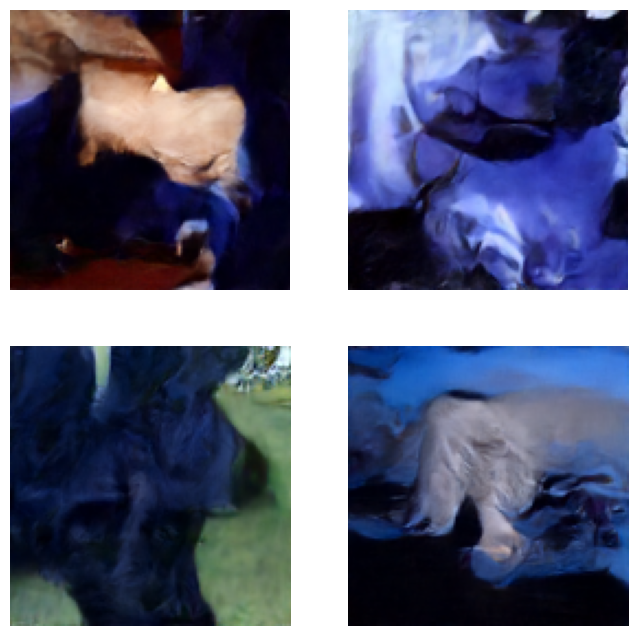

In [13]:
# 生成画像をみる

x = x * 0.5 + 0.5
x = x.clamp(0, 1)

plt.figure(figsize=(8, 8))

for i in range(num_images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(x[i].permute(1, 2, 0).cpu())
    plt.axis("off")
plt.show()

In [ ]:
print("最小値:", x.min().item())
print("最大値:", x.max().item())
print("平均値:", x.mean().item())
print("標準偏差:", x.std().item())

x = torch.randn(
    4,
    3,
    128,
    128,
    device=device
)

print("生成開始時")
print("最小:", x.min().item())
print("最大:", x.max().item())
print("平均:", x.mean().item())
print("標準偏差:", x.std().item())

最小値: 1.0
最大値: 1.0
平均値: 1.0
標準偏差: 0.0
生成開始時
最小: -4.565701484680176
最大: 4.155957221984863
平均: 0.001410095952451229
標準偏差: 1.0041158199310303


In [ ]:
model.eval()

x = torch.randn(
    1,
    3,
    128,
    128,
    device=device
)

for step in reversed(range(T)):
    t = torch.full(
        (1,),
        step,
        device=device,
        dtype=torch.long
    )

    x = reverse_step(x, t)

    if step in [999, 900, 700, 500, 300, 100, 0]:
        print(
            f"t={step}: "
            f"min={x.min().item():.3f}, "
            f"max={x.max().item():.3f}, "
            f"mean={x.mean().item():.3f}, "
            f"std={x.std().item():.3f}"
        )

t=999: min=-3.905, max=4.581, mean=0.003, std=0.999
t=900: min=-4.068, max=4.267, mean=0.023, std=0.995
t=700: min=-4.482, max=4.323, mean=0.153, std=1.005
t=500: min=-4.024, max=4.906, mean=0.526, std=1.023
t=300: min=-3.258, max=5.294, mean=1.157, std=1.060
t=100: min=-1.332, max=4.658, mean=1.725, std=1.058
t=0: min=-0.020, max=3.913, mean=1.822, std=1.004


In [ ]:
torch.save(
    {
        "epoch": 100,
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
    },
    "/content/drive/MyDrive/oxford_pet_generate_model/unet_epoch100.pth"
)

print("Epoch 100のモデルを保存しました！")

Epoch 100のモデルを保存しました！
